In [1]:
import os

print(os.path.exists("data/processed/nav_history_clean.csv"))
print(os.path.exists("data/processed/scheme_performance_clean.csv"))
print(os.path.exists("data/raw/10_benchmark_indices.csv"))

True
True
True


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

nav = pd.read_csv("data/processed/nav_history_clean.csv")

performance = pd.read_csv(
    "data/processed/scheme_performance_clean.csv"
)

benchmark = pd.read_csv(
    "data/raw/10_benchmark_indices.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print(nav.shape)
print(performance.shape)
print(benchmark.shape)

(46000, 3)
(40, 19)
(8050, 3)


In [3]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = nav.groupby(
    "amfi_code"
)["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


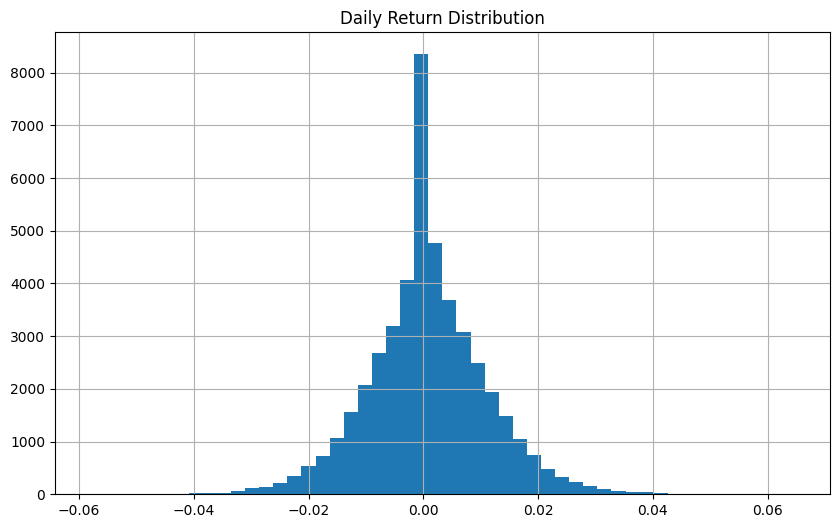

In [4]:
plt.figure(figsize=(10,6))

nav["daily_return"].hist(
    bins=50
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

In [5]:
nav.to_csv(
    "data/processed/nav_with_returns.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [6]:
cagr_results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ].sort_values("date")

    start_nav = temp["nav"].iloc[0]
    end_nav = temp["nav"].iloc[-1]

    years = (
        temp["date"].max()
        -
        temp["date"].min()
    ).days / 365

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
    ) - 1

    cagr_results.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "CAGR"
    ]
)

cagr_df.head()

,amfi_code,CAGR
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [7]:
rf = 0.065

sharpe_results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]

    mean_return = (
        temp["daily_return"].mean()
        * 252
    )

    std_return = (
        temp["daily_return"].std()
        * np.sqrt(252)
    )

    sharpe = (
        mean_return - rf
    ) / std_return

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code", "Sharpe"]
)

sharpe_df.head()

,amfi_code,Sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [8]:
sortino_results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]

    mean_return = (
        temp["daily_return"].mean()
        * 252
    )

    downside = temp[
        temp["daily_return"] < 0
    ]["daily_return"]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    sortino = (
        mean_return - rf
    ) / downside_std

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "Sortino"]
)

sortino_df.head()

,amfi_code,Sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [9]:
drawdowns = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
    ) - 1

    max_dd = temp[
        "drawdown"
    ].min()

    drawdowns.append(
        [code, max_dd]
    )

dd_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "Max_Drawdown"
    ]
)

dd_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [10]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(dd_df)
)

scorecard["score"] = (
    scorecard["CAGR"].rank(pct=True) * 40
    +
    scorecard["Sharpe"].rank(pct=True) * 40
    +
    scorecard["Max_Drawdown"].rank(
        pct=True,
        ascending=False
    ) * 20
)

scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

scorecard.head()

,amfi_code,CAGR,Sharpe,Max_Drawdown,score
25,120505,0.328016,1.180101,-0.181885,88.5
36,148569,0.319245,1.234930,-0.163967,85.5
39,149324,0.322621,0.949796,-0.311719,84.5
21,119598,0.323981,0.945308,-0.287060,84.0
30,120843,0.308833,1.306744,-0.129740,80.5


In [11]:
scorecard.to_csv(
    "reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved")

Fund Scorecard Saved


In [12]:
print(benchmark.columns.tolist())
benchmark.head()

['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [13]:
benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")
    ["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [14]:
alpha_beta_results = []

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "benchmark_return"]]

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty100,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta"
    ]
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [15]:
alpha_beta_df.to_csv(
    "reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


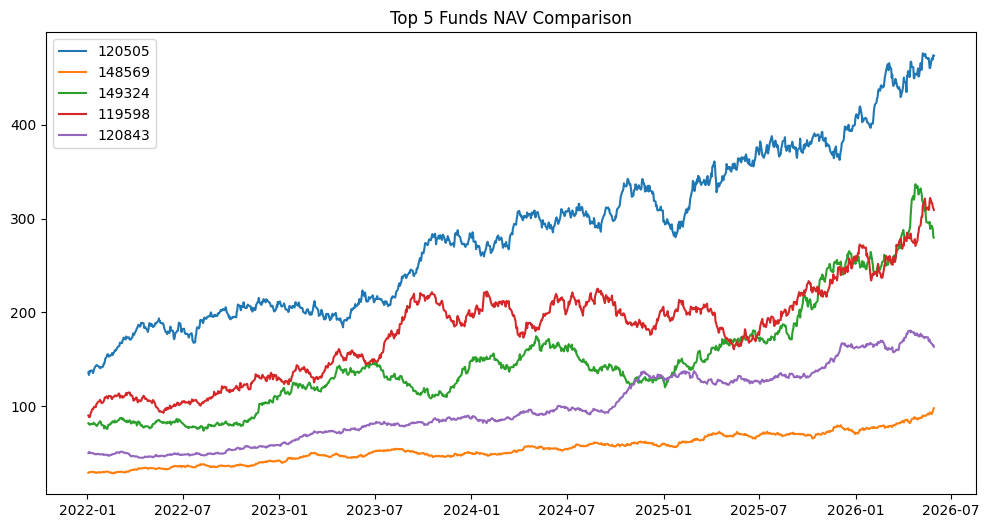

In [16]:
top5 = scorecard.head(5)[
    "amfi_code"
].tolist()

plt.figure(
    figsize=(12,6)
)

for code in top5:

    temp = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.title(
    "Top 5 Funds NAV Comparison"
)

plt.legend()

plt.savefig(
    "reports/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [17]:
final_scorecard = (
    scorecard
    .merge(alpha_beta_df)
)

final_scorecard.head()

,amfi_code,CAGR,Sharpe,Max_Drawdown,score,Alpha,Beta
0,120505,0.328016,1.180101,-0.181885,88.5,0.292636,0.000549
1,148569,0.319245,1.234930,-0.163967,85.5,0.282704,0.018134
2,149324,0.322621,0.949796,-0.311719,84.5,0.300579,0.011455
3,119598,0.323981,0.945308,-0.287060,84.0,0.303370,-0.023196
4,120843,0.308833,1.306744,-0.129740,80.5,0.273305,-0.022830


In [18]:
final_scorecard = (
    scorecard
    .merge(alpha_beta_df)
)

final_scorecard.head()

,amfi_code,CAGR,Sharpe,Max_Drawdown,score,Alpha,Beta
0,120505,0.328016,1.180101,-0.181885,88.5,0.292636,0.000549
1,148569,0.319245,1.234930,-0.163967,85.5,0.282704,0.018134
2,149324,0.322621,0.949796,-0.311719,84.5,0.300579,0.011455
3,119598,0.323981,0.945308,-0.287060,84.0,0.303370,-0.023196
4,120843,0.308833,1.306744,-0.129740,80.5,0.273305,-0.022830


In [19]:
import os

print(
    os.path.exists(
        "reports/fund_scorecard.csv"
    )
)

print(
    os.path.exists(
        "reports/alpha_beta.csv"
    )
)

print(
    os.path.exists(
        "reports/benchmark_comparison.png"
    )
)

True
True
True
